In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, GlobalAveragePooling1D

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mennaahmed23/baby-cry-sense-dataset")

DATASET_ROOT = os.path.join(path, "Baby Cry Dataset")

filepaths = []
labels = []

for label in os.listdir(DATASET_ROOT):
    folder = os.path.join(DATASET_ROOT, label)

    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith((".wav",".ogg",".mp3",".flac")):
                filepaths.append(os.path.join(folder,file))
                labels.append(label)

df = pd.DataFrame({"path":filepaths,"label":labels})

print("Total samples:",len(df))
df.head()

Using Colab cache for faster access to the 'baby-cry-sense-dataset' dataset.
Total samples: 1054


,path,label
0,/kaggle/input/baby-cry-sense-dataset/Baby Cry ...,hungry
1,/kaggle/input/baby-cry-sense-dataset/Baby Cry ...,hungry
2,/kaggle/input/baby-cry-sense-dataset/Baby Cry ...,hungry
3,/kaggle/input/baby-cry-sense-dataset/Baby Cry ...,hungry
4,/kaggle/input/baby-cry-sense-dataset/Baby Cry ...,hungry


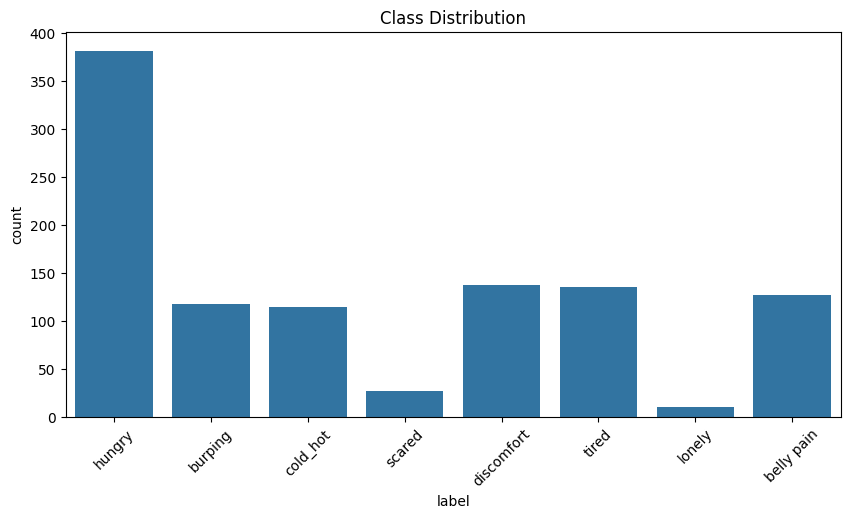

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="label")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

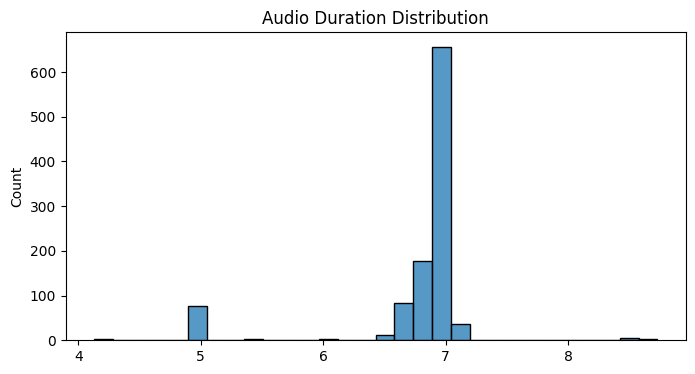

In [ ]:
durations = []

for f in df.path:
    y, sr = librosa.load(f, sr=None)
    durations.append(len(y)/sr)

plt.figure(figsize=(8,4))
sns.histplot(durations,bins=30)
plt.title("Audio Duration Distribution")
plt.show()

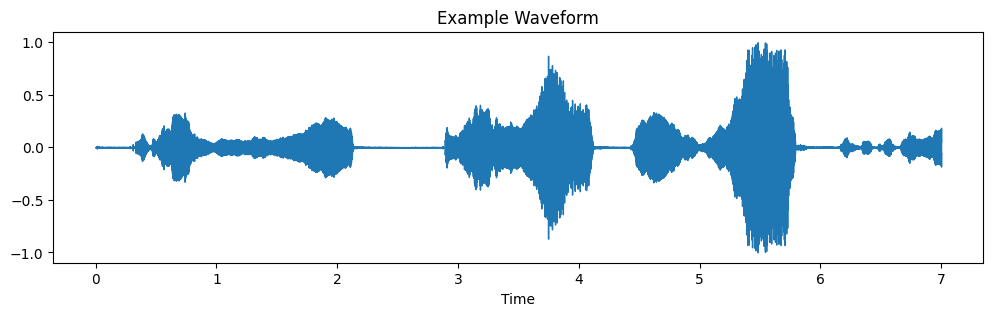

In [ ]:
sample = df.path.iloc[0]
y, sr = librosa.load(sample)

plt.figure(figsize=(12,3))
librosa.display.waveshow(y,sr=sr)
plt.title("Example Waveform")
plt.show()

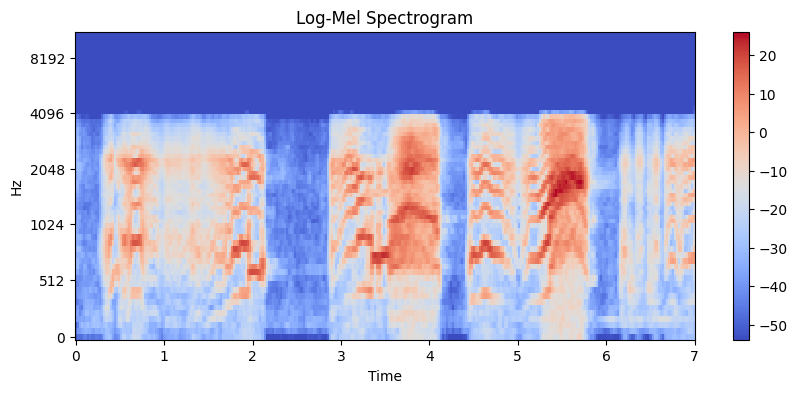

In [ ]:
mel = librosa.feature.melspectrogram(y=y,sr=sr,n_mels=64)
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db,sr=sr,x_axis='time',y_axis='mel')
plt.title("Log-Mel Spectrogram")
plt.colorbar()
plt.show()

In [ ]:
SR = 16000
MAX_LEN = 200
N_MELS = 64

def augment_audio(y,label):

    aug_signals = [y]

    if label in ["lonely","scared","cold_hot"]:
        times = 6
    else:
        times = 3

    for _ in range(times):

        noise = y + 0.005*np.random.randn(len(y))
        shift = np.roll(y,int(0.1*len(y)))
        stretch = librosa.effects.time_stretch(y,rate=0.9)

        aug_signals.extend([noise,shift,stretch])

    return aug_signals


def extract_feature(y):

    y,_ = librosa.effects.trim(y)
    y = librosa.util.normalize(y)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_mels=N_MELS,
        fmax=8000
    )

    mel = librosa.power_to_db(mel)

    if mel.shape[1] < MAX_LEN:
        mel = np.pad(mel,((0,0),(0,MAX_LEN-mel.shape[1])))
    else:
        mel = mel[:,:MAX_LEN]

    return mel

In [ ]:
X = []
y_list = []

for i,row in df.iterrows():

    signal,_ = librosa.load(row.path,sr=SR)

    augmented = augment_audio(signal,row.label)

    for sig in augmented:
        feat = extract_feature(sig)
        X.append(feat)
        y_list.append(row.label)

X = np.array(X)
X = np.transpose(X,(0,2,1))

print("Feature shape:",X.shape)

Feature shape: (11917, 200, 64)


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_list)

num_classes = len(le.classes_)
y_cat = tf.keras.utils.to_categorical(y_encoded)

In [ ]:
X_train,X_temp,y_train,y_temp = train_test_split(
    X,y_cat,
    test_size=0.40,
    stratify=y_encoded,
    random_state=42
)

X_val,X_test,y_val,y_test = train_test_split(
    X_temp,y_temp,
    test_size=0.60,
    stratify=np.argmax(y_temp,axis=1),
    random_state=42
)

In [ ]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train-mean)/std
X_val = (X_val-mean)/std
X_test = (X_test-mean)/std

In [ ]:
model = Sequential()

model.add(Conv1D(64,3,activation='relu',input_shape=(MAX_LEN,N_MELS)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Conv1D(128,3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Bidirectional(LSTM(64,return_sequences=True)))

model.add(GlobalAveragePooling1D())

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(num_classes,activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 198, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 198, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 99, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 97, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 97, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_18                │ (None, 48, 128)        │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,416 (568.03 KB)

 Trainable params: 145,032 (566.53 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=5,
        factor=0.3
    )
]

history = model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=120,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.3404 - loss: 1.7961 - val_accuracy: 0.3867 - val_loss: 1.6790 - learning_rate: 3.0000e-04
Epoch 2/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3986 - loss: 1.6044 - val_accuracy: 0.4239 - val_loss: 1.5090 - learning_rate: 3.0000e-04
Epoch 3/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4316 - loss: 1.4844 - val_accuracy: 0.4523 - val_loss: 1.4003 - learning_rate: 3.0000e-04
Epoch 4/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4503 - loss: 1.3954 - val_accuracy: 0.4570 - val_loss: 1.3329 - learning_rate: 3.0000e-04
Epoch 5/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4920 - loss: 1.2911 - val_accuracy: 0.4790 - val_loss: 1.2725 - learning_rate: 3.0000e-04
Epoch 6/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4992 - loss: 1.2213 - val_accuracy: 0.4717 - val_loss: 1.2293 - learning_rate: 3.0000e-04
Epoch 7/120
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/ste

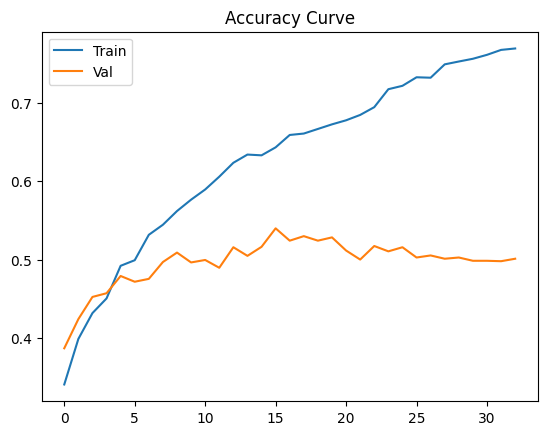

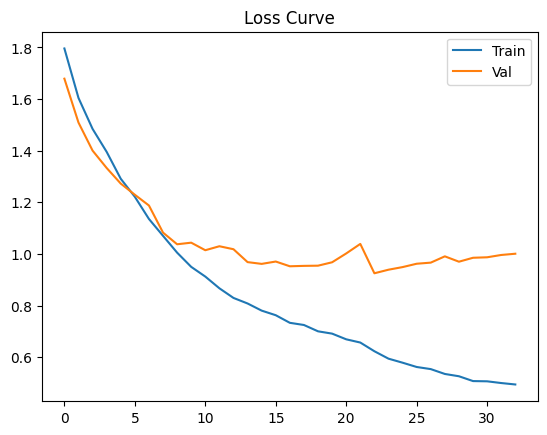

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(["Train","Val"])
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(["Train","Val"])
plt.title("Loss Curve")
plt.show()

In [ ]:
pred = model.predict(X_test)

pred_cls = np.argmax(pred,axis=1)
true_cls = np.argmax(y_test,axis=1)

print(classification_report(
    true_cls,
    pred_cls,
    target_names=le.classes_
))

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

  belly pain       0.61      0.64      0.62       305
     burping       0.59      0.55      0.57       283
    cold_hot       0.65      0.82      0.73       525
  discomfort       0.40      0.34      0.37       331
      hungry       0.37      0.33      0.35       917
      lonely       0.76      0.96      0.85        50
      scared       1.00      1.00      1.00       123
       tired       0.43      0.40      0.41       327

    accuracy                           0.53      2861
   macro avg       0.60      0.63      0.61      2861
weighted avg       0.51      0.53      0.52      2861



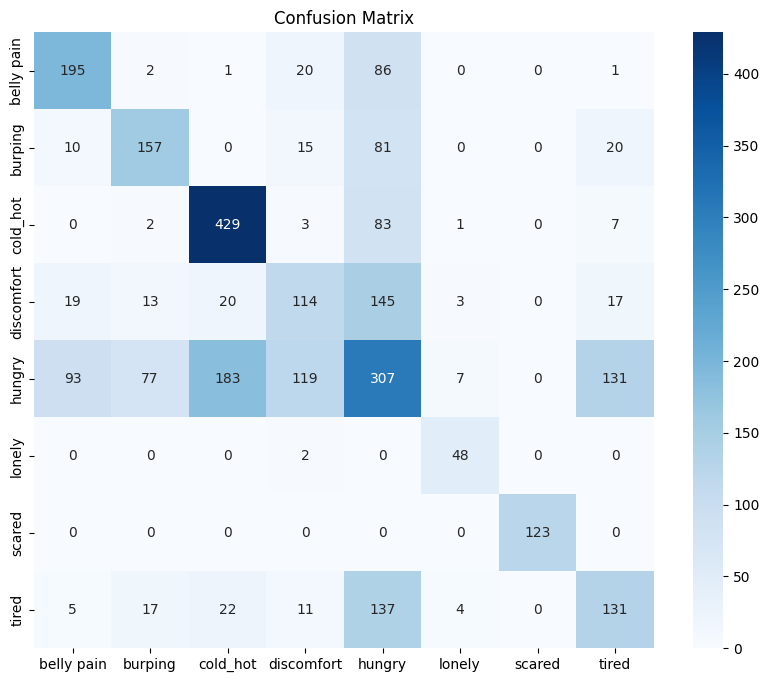

In [ ]:
cm = confusion_matrix(true_cls,pred_cls)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()